Copyright **`(c)`** 2025 Giovanni Squillero `<giovanni.squillero@polito.it>`  
[`https://github.com/squillero/computational-intelligence`](https://github.com/squillero/computational-intelligence)  
Free under certain conditions — see the [`license`](https://github.com/squillero/computational-intelligence/blob/master/LICENSE.md) for details.  

In [35]:
from itertools import product, combinations
import numpy as np
import networkx as nx
from icecream import ic
import time
import math

In [36]:
# modified function (added return of map)
def create_problem(
    size: int,
    *,
    density: float = 1.0,
    negative_values: bool = False,
    noise_level: float = 0.0,
    seed: int = 42,
) -> tuple[np.ndarray, np.ndarray]:
    """Problem generator for Lab3"""
    rng = np.random.default_rng(seed)
    map = rng.random(size=(size, 2))
    problem = rng.random((size, size))
    if negative_values:
        problem = problem * 2 - 1
    problem *= noise_level
    for a, b in product(range(size), repeat=2):
        if rng.random() < density:
            problem[a, b] += np.sqrt(
                np.square(map[a, 0] - map[b, 0]) + np.square(map[a, 1] - map[b, 1])
            )
        else:
            problem[a, b] = np.inf
    np.fill_diagonal(problem, 0)
    return (problem * 1_000).round(), map

In [37]:
## Lab Parameters
sizes = [10, 20, 50, 100 ,200, 500, 1000]
densities = [0.2, 0.5, 0.8, 1.0]
noise_levels = [0.0, 0.1, 0.5, 0.8]
negative_values = [False, True ]


size = sizes[6]
density = densities[1]
noise_level = noise_levels[1]
negative_value = negative_values[0]

#create of the problem
problem, map = create_problem(size, density=density, noise_level=noise_level, negative_values=negative_value)
masked = np.ma.masked_array(problem, mask=np.isinf(problem))
G = nx.from_numpy_array(masked, create_using=nx.DiGraph)
print(f"Problem size: {size} nodes, Negative values: {negative_value}, Density: {density}, Noise level: {noise_level}")


Problem size: 1000 nodes, Negative values: False, Density: 0.5, Noise level: 0.1


In [ ]:
"""
for s, d in combinations(range(size), 2):
    try:
        #path = nx.shortest_path(G, s, d, weight='weight')
        path = nx.bellman_ford_path(G, s, d, weight='weight')
        cost = cost = nx.path_weight(G, path, weight='weight')
    except nx.NetworkXNoPath:
        # Nodes are not connected
        path = None
        cost = np.inf
    except nx.NetworkXUnbounded:
        # Negative cycle detected
        path = None
        cost = -np.inf
    ic(s, d, path, cost)
None
"""

Algorithm A*

In [39]:
def euclidean_heuristic(u, v, map):
    """A* heuristic: scaled straight-line (Euclidean) distance."""
    x1, y1 = map[u]
    x2, y2 = map[v]
    dist = math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)
    return round(dist*1_000)

In [40]:
import heapq as hq
import sys

INF = float('inf')

def astar_manual(G, source, target, heuristic, weight='weight'):
    """
    Manual simplified implementation of A* (simulates nx.astar_path).

    It does not correctly handle negative weights or cycles (just like standard Dijkstra/A*).
    """
    
    # g(n): real cost from start to n
    g_score = {node: INF for node in G.nodes()}
    g_score[source] = 0
    
    # f(n): estimated cost (g(n) + h(n))
    f_score = {node: INF for node in G.nodes()}
    f_score[source] = heuristic(source, target)
    
    # priority queue: (f_score, node, path_so_far)
    # Using heapq simulates A* behavior
    queue = [(f_score[source], source, [source])]
    
    while queue:
        # Extract the node with the lowest f_score
        f_current, current_node, current_path = hq.heappop(queue)
        
        if current_node == target:
            return current_path
        
        # If the extracted f_score is worse than the known g_score, skip (optimization)
        if f_current > g_score[current_node] + heuristic(current_node, target):
             continue

        for neighbor, edge_data in G.adj[current_node].items():
            
            # Calculate the edge cost (weight)
            edge_weight = edge_data.get(weight, 1)
            
            # g_temp: Real cost to reach the neighbor through the current node
            g_temp = g_score[current_node] + edge_weight
            
            if g_temp < g_score[neighbor]:
                
                # Found a better path-> Update scores
                g_score[neighbor] = g_temp
                
                # Calculate the new f_score (g_temp + h)
                f_score[neighbor] = g_temp + heuristic(neighbor, target)
                
                new_path = current_path + [neighbor]
                
                # Add the neighbor to the queue
                hq.heappush(queue, (f_score[neighbor], neighbor, new_path))
                
    raise nx.NetworkXNoPath()

In [41]:
import random
import matplotlib.pyplot as plt
import pandas as pd


NUM_PAIRS_TO_TEST = 200  # number of random pairs to test REMEMBER TO CHANGE 
#selection of all possible pairs
all_possible_pairs = list(combinations(range(size), 2))
num_testable_pairs = len(all_possible_pairs)

# selection of N random pairs without repetition
num_pairs_to_sample = min(NUM_PAIRS_TO_TEST, num_testable_pairs)
random_test_pairs = random.sample(all_possible_pairs, num_pairs_to_sample)

print(f"Randomly selected pairs: {random_test_pairs}")
# comparison on selected pairs

results = []
time_data = {'Astar': 0.0, 'Dijkstra': 0.0, 'Optimal': 0.0}
time_data = {'Astar': 0.0, 'Dijkstra': 0.0, 'Optimal': 0.0}
h = lambda u, v: euclidean_heuristic(u, v, map)
for s, d in random_test_pairs:

    cost_astar = float('nan')
    cost_optimal = float('nan')
    cost_dijkstra = float('nan')

    # 1. OPTIMAL (bellman-ford)
    start_time = time.time()
    try:
        path = nx.bellman_ford_path(G, s, d, weight='weight')
        cost_optimal = nx.path_weight(G, path, weight='weight')
    except nx.NetworkXNoPath:
        cost_optimal = np.inf
    except nx.NetworkXUnbounded:
        cost_optimal = -np.inf
    time_data['Optimal'] += (time.time() - start_time)

    # 2. A* manual implementation
    start_time = time.time()
    try:
        path_astar = astar_manual(G, s, d, heuristic=h, weight='weight')
        cost_astar = nx.path_weight(G, path_astar, weight='weight')
    except nx.NetworkXNoPath:
        cost_astar = np.inf
    except Exception:
        cost_astar = float('nan')
    time_data['Astar'] += (time.time() - start_time)


    # 3. Dijkstra
    start_time = time.time()
    try:
        cost_dijkstra = nx.shortest_path_length(G, s, d, weight='weight')
    except nx.NetworkXNoPath:
        cost_dijkstra = np.inf
    except ValueError as e:
        if 'negative' in str(e):
            cost_dijkstra = float('nan')
        else: cost_dijkstra = np.inf
    except Exception:
        cost_dijkstra = np.inf
    time_data['Dijkstra'] += (time.time() - start_time)

    # Data collection
    if cost_optimal> 0 and cost_optimal<np.inf:
       error_astar = abs(cost_astar - cost_optimal) / cost_optimal if cost_astar < np.inf and not np.isnan(cost_astar) else float('nan')
       error_dijkstra = abs(cost_dijkstra - cost_optimal) / cost_optimal if cost_dijkstra < np.inf and not np.isnan(cost_dijkstra) else float('nan')

       results.append({
            'source': s, 'dest': d, 'Optimal_Cost': cost_optimal,
            'Astar_Cost': cost_astar, 'Dijkstra_Cost': cost_dijkstra,
            'Error_Astar': error_astar, 'Error_Dijkstra': error_dijkstra
        })
       print(f"  {s}->{d}: Opt={cost_optimal:.0f}, A*={cost_astar:.0f}, Dij={cost_dijkstra:.0f}, Err_A*={error_astar:.2f}, Err_Dij={error_dijkstra:.2f}")
    
# analysis and plotting of results
df_results = pd.DataFrame(results)
# Aggregation for times
df_times = pd.DataFrame({
    'Algorithm': ['Astar', 'Dijkstra', 'Optimal'],
    'Time': [time_data['Astar'], time_data['Dijkstra'], time_data['Optimal']]
})



Randomly selected pairs: [(289, 863), (555, 783), (918, 933), (241, 346), (278, 948), (607, 923), (595, 990), (692, 878), (118, 410), (62, 200), (709, 940), (80, 978), (76, 250), (50, 178), (613, 913), (26, 59), (299, 990), (24, 249), (607, 982), (70, 735), (104, 846), (673, 949), (446, 584), (301, 983), (514, 694), (100, 367), (227, 313), (353, 524), (200, 399), (16, 635), (331, 783), (104, 549), (56, 80), (616, 903), (905, 963), (2, 116), (523, 579), (335, 848), (686, 731), (219, 741), (429, 963), (638, 964), (110, 984), (104, 917), (410, 911), (150, 587), (317, 654), (130, 152), (507, 541), (311, 554), (151, 412), (103, 140), (24, 530), (86, 593), (340, 505), (3, 393), (298, 523), (640, 698), (142, 177), (116, 792), (198, 259), (607, 799), (121, 740), (49, 809), (257, 300), (505, 610), (283, 736), (167, 532), (105, 189), (952, 977), (338, 942), (542, 785), (298, 380), (123, 343), (410, 454), (172, 549), (610, 728), (28, 335), (493, 554), (212, 457), (27, 897), (44, 399), (309, 627),

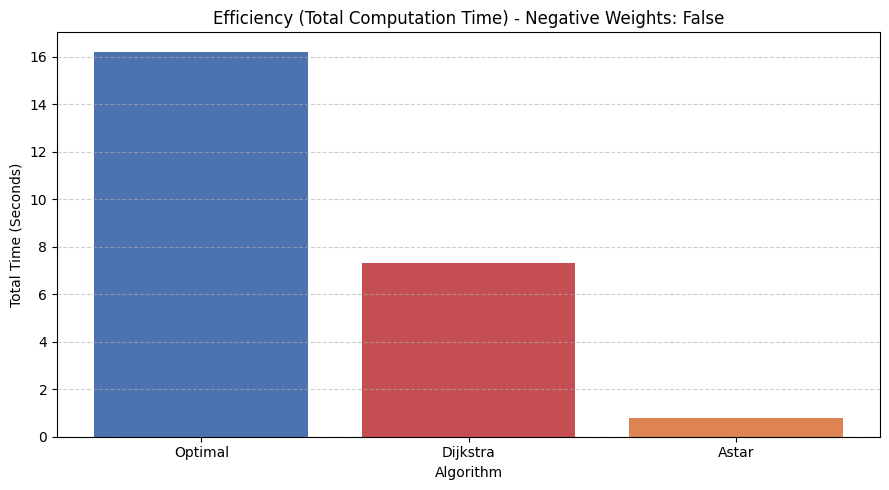

In [42]:
def plot_time_comparison(df_times, neg_val):
    """
    Display the total execution times for A*, Dijkstra, and Bellman–Ford.

    Args:
    df_times (pd.DataFrame): DataFrame containing the columns 'Algorithm' and 'Time'.
    neg_val (bool): Indicates whether negative weights were present (used in the title).
    """
    
    plt.figure(figsize=(9, 5))
    
    # Sort to see the slowest immediately
    df_times = df_times.sort_values(by='Time', ascending=False)
    
    # Distinctive colors: Optimal (Baseline), Heuristic (A*), Failure (Dijkstra)
    colors = {'Optimal': '#4c72b0', 'Astar': '#dd8452', 'Dijkstra': '#c44e52'}
    
    plt.bar(df_times['Algorithm'], df_times['Time'], 
            color=[colors[alg] for alg in df_times['Algorithm']])
    
    plt.title(f'Efficiency (Total Computation Time) - Negative Weights: {neg_val}')
    plt.xlabel('Algorithm')
    plt.ylabel('Total Time (Seconds)')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

plot_time_comparison(df_times, negative_value)